# A multi-kernel step, declaratively

A physical step sometimes needs more than one kernel: advance the state,
derive a diagnostic from it, then decide whether to stop. This tutorial
builds that step two ways — one `simulate` call, then the same loop by hand,
piece by piece, so you can see (and reuse) what the call puts together.

**Time:** ~7 min · **Runs on:** CPU, GPU if visible (picked up automatically)
· **You need:** {doc}`02_cuda_graphs_python` (`Plan.bind`, `GraphPipeline`) and
{doc}`06_compaction_and_reorder` (`ActiveSet`, compaction).

You will build: an ensemble of damped oscillators settling toward rest, and
a plot of where each one's energy ends up.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent.parent / "_shared"))
from nb_helpers import gpu_available, plot_style, xp_for
plot_style()

In [2]:
DEVICE = "gpu" if gpu_available() else "cpu"
xp = xp_for(DEVICE)
print("running on", DEVICE)

running on cpu


In [3]:
import numpy as np

import hawk
from hawk import Mutable, Param, Scalar, Terminated
from hawk.ext import Guard, Kind

from eagle import (
    ActiveSet, GraphPipeline, SkipGuard, compaction_body,
    deploy, repeat_while, simulate,
)

## Three short kernels, one shared guard

`propagate` advances `(x, v)` one semi-implicit Euler step; `diagnostic` turns
the new state into a mechanical energy; `event` compares that energy against a
threshold and is the one that sets `terminated`. Each is an ordinary
per-sample function — no index arithmetic, no masks read or written by hand.
`hawk.ext.Guard(active_set=True)` makes every one of them read eagle's
active-set index map (`active_map` / `active_count`): once a sample settles it
no longer costs a thread in any of the three launches.

In [4]:
def propagate(omega: Param, zeta: Param, dt: Param, terminated: Terminated,
              x: Mutable[Scalar], v: Mutable[Scalar]):
    """One semi-implicit Euler step of a damped harmonic oscillator."""
    x0, v0 = x, v
    a = -(omega * omega) * x0 - 2.0 * zeta * omega * v0
    v_new = v0 + dt * a
    v = v_new
    x = x0 + dt * v_new


def diagnostic(x: Scalar, v: Scalar, omega: Param, terminated: Terminated,
               energy: Mutable[Scalar]):
    """The sample's mechanical energy -- frozen once it settles."""
    energy = 0.5 * v * v + 0.5 * omega * omega * x * x


def event(energy: Scalar, eps: Param, terminated: Terminated):
    """The settling event: terminate once the energy decays below eps."""
    terminated = energy < eps


# One shared Kind: all three kernels gate on the same active set.
STEP = Kind("ensemble_step", guard=Guard(active_set=True))
kernels = [hawk.kernel(fn, kind=STEP) for fn in (propagate, diagnostic, event)]

## The one call

`simulate` runs the kernels in list order, as one step. Pass the
arguments as you would call the kernels: an array gives each sample its
own value (`x`, `v`), a plain number is shared by every sample (`omega`,
`zeta`, `dt`, `eps`); `energy`, written by `diagnostic`, is allocated for
you. The step stops for a sample once `event` marks it, and the batch
stops when every sample has settled or after `max_steps`. Each launch
takes one step.

In [5]:
n = 20_000
x0 = np.random.default_rng(3).uniform(-1.0, 1.0, n)

In [6]:
result = simulate(kernels, x=xp.asarray(x0), v=xp.zeros(n),
                  omega=3.0, zeta=0.15, dt=0.01, eps=0.01,
                  max_steps=600, every=16)
n_settled = int(result.finished.sum())
print(result.status, f"after {result.steps} steps:",
      f"{n_settled} / {n} settled; allocated for you: {result.allocated}")

max_steps after 608 steps: 15597 / 20000 settled; allocated for you: ('energy',)


The rest of this tutorial builds that loop by hand: the same plans, the same
active set and the same bounded loop, written out one piece at a time.

## What it builds: one plan per kernel

`eagle.deploy(kernels)` compiles all three kernels into one hawk bundle
(through hawk's build cache, so a rerun compiles nothing) and returns one
plan per kernel, in order. Each plan runs where the data it is bound to
lives: cupy arrays select `eagle.exec.DeviceKernel` on the GPU, numpy arrays
`eagle.exec.HostTeam` on the CPU.

In [7]:
propagate_plan, diagnostic_plan, event_plan = deploy(kernels)

## `ActiveSet`: one shared live-sample map

Allocate the ensemble's own arrays, then wrap the `terminated` mask in
{class}`~eagle.ActiveSet`. `active.planes()` hands back the `active_map` /
`active_count` planes every compacting kernel above reads — all three
launches will agree on exactly which samples are still live.

In [8]:
n = 20_000
rng = np.random.default_rng(3)
omega, zeta, dt, eps = 3.0, 0.15, 0.01, 0.01

x = xp.asarray(rng.uniform(-1.0, 1.0, n))
v = xp.zeros(n)
energy = xp.zeros(n)
terminated = xp.zeros(n, dtype=xp.bool_)
finished = xp.zeros(1, dtype=xp.uint32)
total = xp.asarray([n], dtype=xp.uint32)

active = ActiveSet(terminated)

## `Plan.bind`: pack the arguments once, compose the step

`Plan.bind` (the capture-legal door {doc}`02_cuda_graphs_python` introduced)
packs each kernel's arguments against the ensemble's own arrays, once.
`one_step` is the whole physical step: three `launch()` calls, in order,
nothing else.

In [9]:
propagate_run = propagate_plan.bind(
    omega=omega, zeta=zeta, dt=dt, terminated=terminated, x=x, v=v, **active.planes())
diagnostic_run = diagnostic_plan.bind(
    x=x, v=v, omega=omega, terminated=terminated, energy=energy, **active.planes())
event_run = event_plan.bind(
    energy=energy, eps=eps, terminated=terminated,
    finished_count=finished, **active.planes())


def one_step():
    propagate_run.launch()
    diagnostic_run.launch()
    event_run.launch()

## `compaction_body`: recompute the map every few steps

{func}`~eagle.compaction_body` wraps `one_step` so that every `every` steps,
{class}`~eagle.ActiveSet` recomputes the live-sample map on the device, inside
the same graph -- the three launches above start covering only the samples
still running.

In [10]:
every, max_steps = 16, 600
body = compaction_body(one_step, active, every=every, finished=finished)

## `repeat_while` + `SkipGuard`: one bounded loop

{func}`~eagle.repeat_while` under a {class}`~eagle.SkipGuard` turns `body`
into a single bounded loop: it stops the moment every sample has settled
(`finished == total`), or after `max_steps`, whichever comes first.

In [11]:
loop = repeat_while(body, SkipGuard(finished, 0, total, 0), -(-max_steps // every))

## Capture once, replay -- or just run it

On the GPU, {class}`~eagle.GraphPipeline` records `loop` into one CUDA graph
and replays it; nothing above had to change to make that legal, because every
step and every compaction already only touch pre-allocated arrays. On the CPU
there is no graph to capture — {func}`~eagle.repeat_while` runs the same
`loop` as a plain Python loop when called directly. Either way it is the same
few lines below, and the results read back the same way.

In [12]:
if DEVICE == "gpu":
    GraphPipeline().add(loop).build().launch()
    xp.cuda.Device().synchronize()
else:
    loop()

n_live = n - active.live
print(f"{loop.iterations()} compaction cycles, {n_live} / {n} settled, "
      f"{active.live} still oscillating")
print(f"energy remaining in the batch: {float(xp.sum(energy)):.3f}")

38 compaction cycles, 15597 / 20000 settled, 4403 still oscillating
energy remaining in the batch: 206.291


This hand-built loop reaches the exact same state as the `simulate` call
above -- same `x`, same `terminated` -- because it is the same three
launches, the same active set and the same stop rule, just composed by
hand instead of in one call.

In [13]:
print("the same state as the simulate call above:",
      bool(xp.all(x == result.x)) and bool(xp.all(terminated == result.finished)))

the same state as the simulate call above: True


## What settled, and how fast

Each sample's final energy against where it started: settled samples (the
active-set map dropped them) cluster near zero, the rest are still
oscillating when the batch hit `max_steps`.

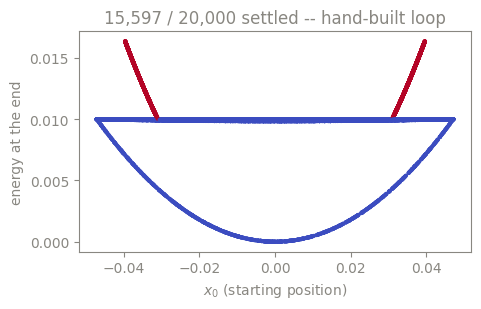

In [14]:
import matplotlib.pyplot as plt
from nb_helpers import to_numpy

energy_host = to_numpy(energy)
terminated_host = to_numpy(terminated)

fig, ax = plt.subplots(figsize=(5, 3.2))
sc = ax.scatter(x0, energy_host, s=4, c=terminated_host, cmap="coolwarm_r")
ax.set_xlabel(r"$x_0$ (starting position)")
ax.set_ylabel("energy at the end")
ax.set_title(f"{int(terminated_host.sum()):,} / {n:,} settled -- hand-built loop")
fig.tight_layout()
plt.show()

## `simulate`, `run_until_done` and this path

{func}`~eagle.simulate` is the call to reach for first. Given one kernel that
both advances the state and finishes its own samples, it runs
{func}`~eagle.run_until_done` (an automatic number of steps per launch, picked
as the samples finish); given several, it composes exactly the loop above.
Composing `Plan`, `GraphPipeline`, `ActiveSet` and `repeat_while` yourself,
as here, is just as declarative, one level down, and stays the path for a loop
that does more than step: a step that alternates kernels, extra work between
compactions, or a larger graph the loop is one piece of.

## Next

- {doc}`06_compaction_and_reorder` -- the active-set map on its own, with the
  numbers for when it pays.
- deeper: {doc}`../../performance` -- the same loop shape, measured.